In [27]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [28]:
df_org=pd.read_csv('Telco_churn_dataset.csv')

In [29]:
df_org.sample(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2602,1135-HIORI,Female,0,Yes,Yes,64,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,111.45,7266.95,No
100,6380-ARCEH,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.2,No
1326,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,Yes,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No
4639,7402-EYFXX,Male,1,No,No,26,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,93.60,2404.1,No


In [30]:
X = df_org.drop('Churn', axis=1)
Y = df_org['Churn']

In [31]:
Y = Y.map({
    'Yes':1,
    'No':0
})
Y = Y.astype(int)

In [32]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int32

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer)
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (

    accuracy_score,

    classification_report,

    confusion_matrix
)




num_columns = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

multi_columns = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

binary_columns = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
]


def basic_cleaning(df1):

    df1 = df1.copy()

    # Remove customerID
    df1 = df1.drop('customerID', axis=1)

    # Convert TotalCharges
    df1['TotalCharges'] = pd.to_numeric(df1['TotalCharges'],errors='coerce')

    # Fill missing values
    df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())

    # Binary mapping
    binary_map = {
        'Yes':1,
        'No':0,
        'Female':0,
        'Male':1
    }

    for col in binary_columns:
        df1[col] = df1[col].map(binary_map)

    return df1

In [35]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_columns ),
                                  ('cat', OneHotEncoder(drop='first'),multi_columns)
                                  ],remainder='passthrough')

In [36]:
logistic_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', LogisticRegression())])

In [37]:
logistic_pipe.fit(X_train, y_train)

,steps,"[('cleaning', ...), ('preprocessing', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function bas...001EFC35C3380>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


In [38]:
y_pred = logistic_pipe.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score

print("Accuracy:",accuracy_score(y_test, y_pred)*100)

Accuracy: 82.11497515968772


In [41]:
acc_list=[]
iters = [50, 100, 200, 500, 1000, 2000, 3000, 5000, 7000, 10000]
for i in iters:

    logistic_pipe = Pipeline([
    ('cleaning',FunctionTransformer(basic_cleaning)),
    ('preprocessing',preprocessor),
    ('model', LogisticRegression(max_iter=i))])



    logistic_pipe.fit(X_train, y_train)
    
    y_pred = logistic_pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)
    
    print(f"max_iter = {i:<5} | Accuracy = {acc * 100:.2f}%")

max_iter = 50    | Accuracy = 82.11%
max_iter = 100   | Accuracy = 82.11%
max_iter = 200   | Accuracy = 82.11%
max_iter = 500   | Accuracy = 82.11%
max_iter = 1000  | Accuracy = 82.11%
max_iter = 2000  | Accuracy = 82.11%
max_iter = 3000  | Accuracy = 82.11%
max_iter = 5000  | Accuracy = 82.11%
max_iter = 7000  | Accuracy = 82.11%
max_iter = 10000 | Accuracy = 82.11%


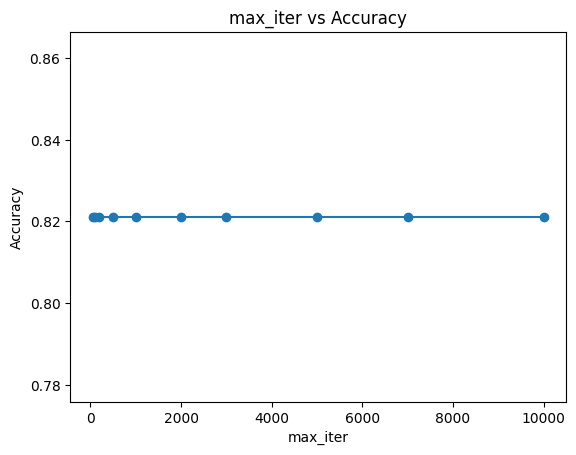

In [42]:
# Graph
import matplotlib.pyplot as plt
plt.plot(iters, acc_list, marker='o')

plt.xlabel("max_iter")
plt.ylabel("Accuracy")
plt.title("max_iter vs Accuracy")

plt.show()

In [44]:
#Accuracy is same because the model already converged early.

# That means after some iterations, the weights stop changing significantly.

# So increasing max_iter further does not improve learning.